# 03 — Tuning Results & Final Model Comparison

**Mục tiêu:**
1. Hiển thị kết quả Hyperparameter Tuning (Optuna) cho 4 mô hình
2. So sánh F1 / Recall / Precision sau khi tuning
3. Đề xuất mô hình tốt nhất

> **Lưu ý:** Notebook này cần chạy SAU khi pipeline tuning đã hoàn tất:  
> `python run_pipeline.py --step tune --sampling smote`  
> `python run_pipeline.py --step train --sampling smote`

In [1]:
import sys
from pathlib import Path
import json

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import REPORTS_DIR, MODELS_DIR, MODEL_NAMES
from src.models import get_model_display_name

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120})

## 1. Load Tuning Results (Best Params)

In [2]:
tuning_results = []

for name in MODEL_NAMES:
    params_file = REPORTS_DIR / f'best_params_{name}.json'
    if params_file.exists():
        with open(params_file) as f:
            data = json.load(f)
        print(f'\n✅ {get_model_display_name(name)}:')
        print(f'   Best F1: {data["best_f1"]:.4f}')
        print(f'   Params:  {json.dumps(data["params"], indent=2)}')
        tuning_results.append({
            'Model': get_model_display_name(name),
            'Best CV F1': data['best_f1'],
            'Best Params': json.dumps(data['params']),
        })
    else:
        print(f'\n❌ {get_model_display_name(name)}: No tuning results found')
        print(f'   Run: python run_pipeline.py --step tune --models {name[:2]}')

if tuning_results:
    tuning_df = pd.DataFrame(tuning_results)
    print('\n' + '='*60)
    print(tuning_df[['Model', 'Best CV F1']].to_string(index=False))


✅ Random Forest:
   Best F1: 0.9999
   Params:  {
  "n_estimators": 200,
  "max_depth": 30,
  "min_samples_split": 5,
  "class_weight": "balanced"
}

✅ Logistic Regression:
   Best F1: 0.9524
   Params:  {
  "C": 0.9808314477979637,
  "l1_ratio": 0.16227285374345743,
  "class_weight": null
}

✅ K-Nearest Neighbors:
   Best F1: 0.9964
   Params:  {
  "n_neighbors": 3,
  "weights": "distance",
  "metric": "manhattan"
}

✅ Support Vector Machine:
   Best F1: 0.9988
   Params:  {
  "kernel": "rbf",
  "C": 28.477948820003977,
  "class_weight": "balanced",
  "gamma": "auto"
}

                 Model  Best CV F1
         Random Forest    0.999888
   Logistic Regression    0.952369
   K-Nearest Neighbors    0.996437
Support Vector Machine    0.998771


## 2. Load Training & Evaluation Results

In [3]:
# Try to load the model comparison CSV
comparison_files = list(REPORTS_DIR.glob('model_comparison_*.csv'))
print(f'Found {len(comparison_files)} comparison file(s):')
for f in comparison_files:
    print(f'  → {f.name}')

# Load the most relevant one (smote or latest)
all_comparisons = []
for f in comparison_files:
    df_comp = pd.read_csv(f)
    all_comparisons.append(df_comp)

if all_comparisons:
    results_df = pd.concat(all_comparisons, ignore_index=True)
    print('\n📊 Combined Results:')
    print(results_df.to_string(index=False))
else:
    print('\n⚠️ No comparison files found. Run the training pipeline first.')
    results_df = pd.DataFrame()

Found 2 comparison file(s):
  → model_comparison_smote.csv
  → model_comparison_baseline.csv

📊 Combined Results:
                 model               sampling  accuracy  precision  recall  f1_score  auc_roc  auc_pr
         Random Forest                  smote    0.9995     0.8469  0.8469    0.8469   0.9661  0.8732
   Logistic Regression                  smote    0.9747     0.0591  0.9184    0.1110   0.9713  0.7222
   K-Nearest Neighbors                  smote    0.9985     0.5449  0.8673    0.6693   0.9434  0.6005
Support Vector Machine                  smote    0.9988     0.6739  0.6327    0.6526   0.8517  0.6294
   Logistic Regression baseline (no sampling)    0.9754     0.0606  0.9184    0.1138   0.9719  0.7093


## 3. Visualisation — Model Performance Comparison

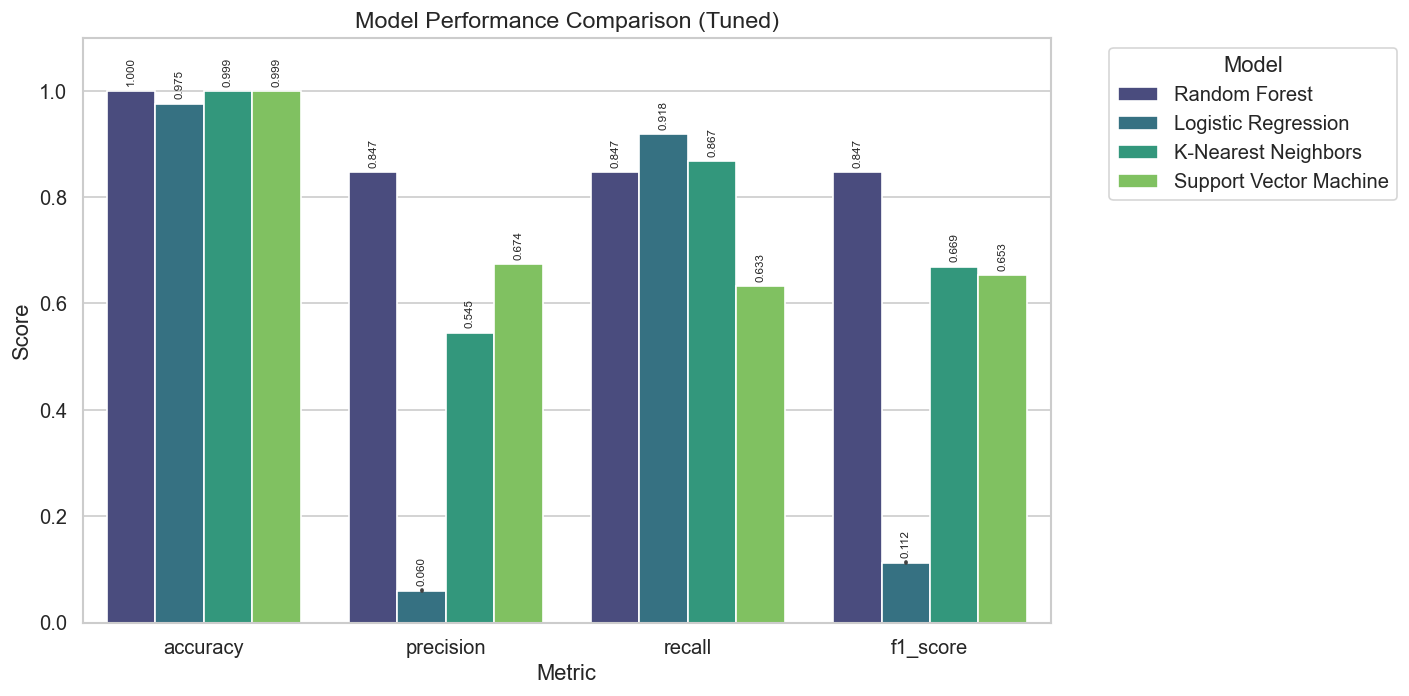

In [4]:
if not results_df.empty:
    metrics_cols = ['accuracy', 'precision', 'recall', 'f1_score']
    available_metrics = [m for m in metrics_cols if m in results_df.columns]
    
    # Grouped bar chart
    melted = results_df.melt(
        id_vars=['model', 'sampling'], 
        value_vars=available_metrics,
        var_name='Metric', value_name='Score'
    )
    
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.barplot(data=melted, x='Metric', y='Score', hue='model', ax=ax,
                palette='viridis')
    ax.set_title('Model Performance Comparison (Tuned)', fontsize=14)
    ax.set_ylim([0, 1.1])
    ax.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Value labels
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=7, rotation=90, padding=3)
    
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_model_comparison.png'))
    plt.show()
else:
    print('No results to plot.')

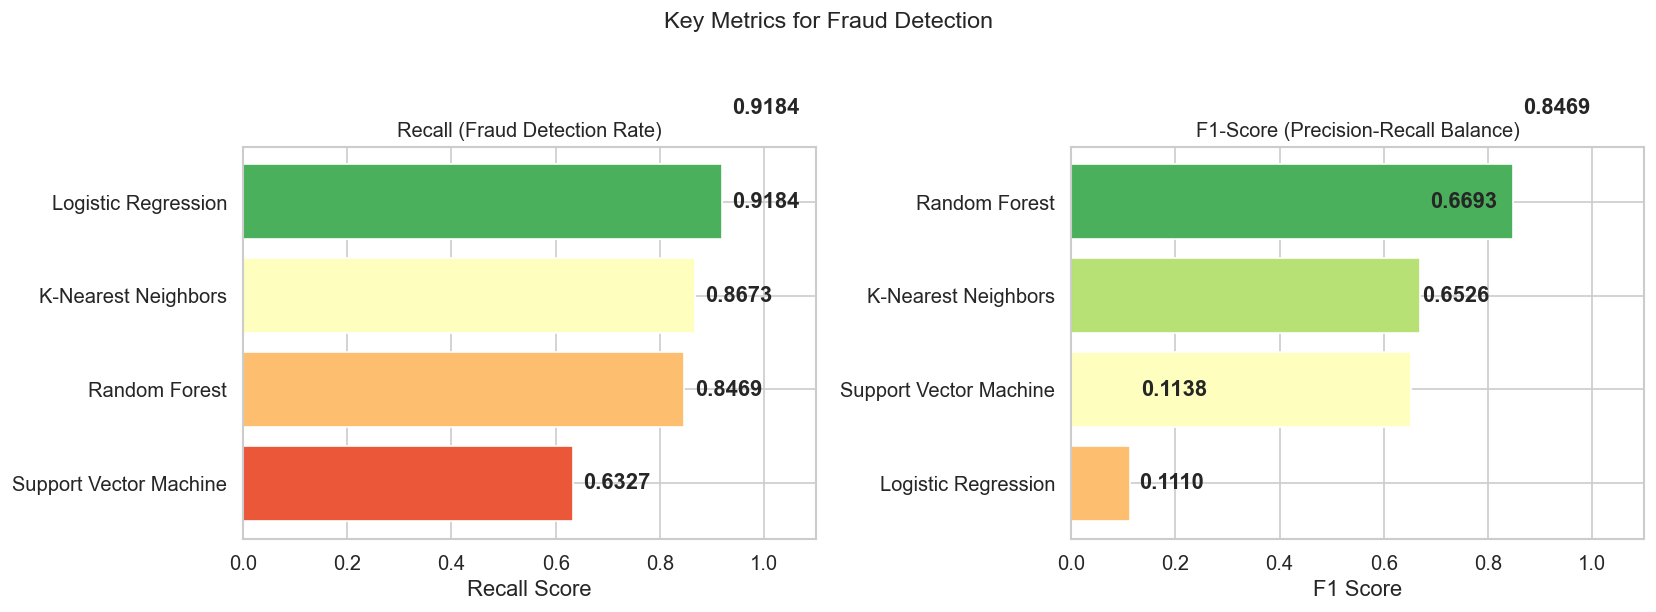

In [5]:
# Focus on Recall and F1 (the most important metrics for fraud detection)
if not results_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Recall comparison
    if 'recall' in results_df.columns:
        recall_sorted = results_df.sort_values('recall', ascending=True)
        colors = sns.color_palette('RdYlGn', len(recall_sorted))
        axes[0].barh(recall_sorted['model'], recall_sorted['recall'], color=colors)
        axes[0].set_title('Recall (Fraud Detection Rate)', fontsize=12)
        axes[0].set_xlabel('Recall Score')
        axes[0].set_xlim([0, 1.1])
        for i, (v, name) in enumerate(zip(recall_sorted['recall'], recall_sorted['model'])):
            axes[0].text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')
    
    # F1 comparison
    if 'f1_score' in results_df.columns:
        f1_sorted = results_df.sort_values('f1_score', ascending=True)
        colors = sns.color_palette('RdYlGn', len(f1_sorted))
        axes[1].barh(f1_sorted['model'], f1_sorted['f1_score'], color=colors)
        axes[1].set_title('F1-Score (Precision-Recall Balance)', fontsize=12)
        axes[1].set_xlabel('F1 Score')
        axes[1].set_xlim([0, 1.1])
        for i, (v, name) in enumerate(zip(f1_sorted['f1_score'], f1_sorted['model'])):
            axes[1].text(v + 0.02, i, f'{v:.4f}', va='center', fontweight='bold')
    
    plt.suptitle('Key Metrics for Fraud Detection', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_recall_f1_comparison.png'))
    plt.show()

## 4. ROC-AUC & AUC-PR Comparison

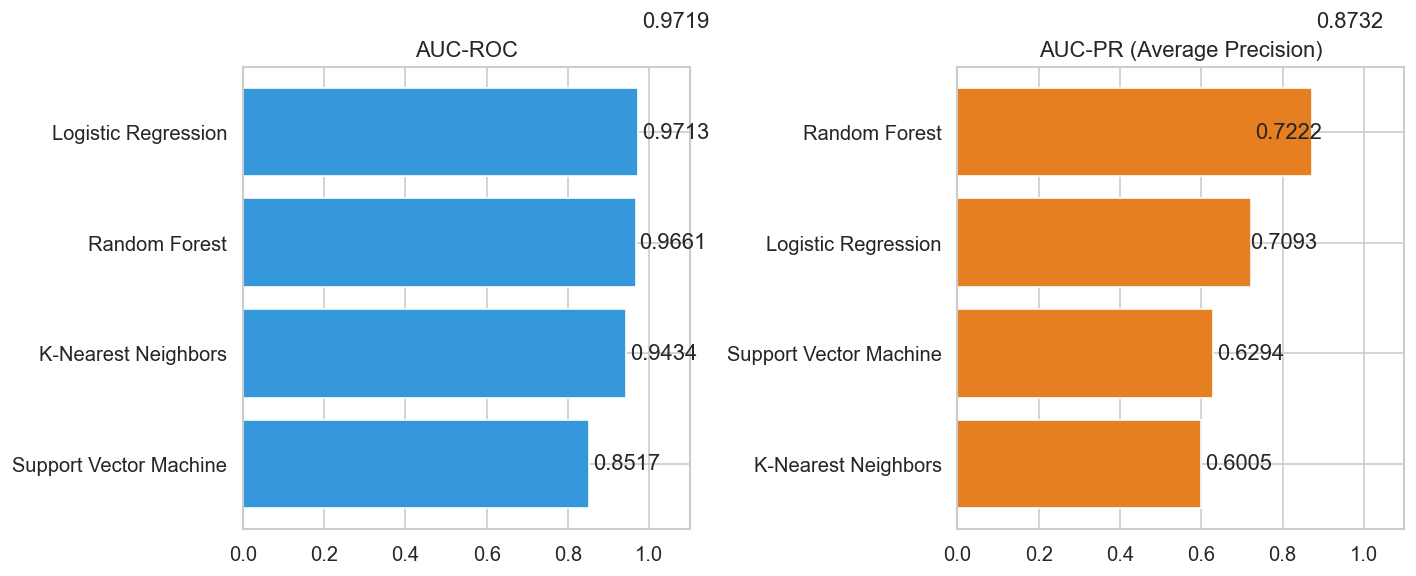

In [6]:
if not results_df.empty and 'auc_roc' in results_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # AUC-ROC
    sorted_roc = results_df.sort_values('auc_roc', ascending=True)
    axes[0].barh(sorted_roc['model'], sorted_roc['auc_roc'], color='#3498db')
    axes[0].set_title('AUC-ROC')
    axes[0].set_xlim([0, 1.1])
    for i, v in enumerate(sorted_roc['auc_roc']):
        axes[0].text(v + 0.01, i, f'{v:.4f}', va='center')
    
    # AUC-PR
    if 'auc_pr' in results_df.columns:
        sorted_pr = results_df.sort_values('auc_pr', ascending=True)
        axes[1].barh(sorted_pr['model'], sorted_pr['auc_pr'], color='#e67e22')
        axes[1].set_title('AUC-PR (Average Precision)')
        axes[1].set_xlim([0, 1.1])
        for i, v in enumerate(sorted_pr['auc_pr']):
            axes[1].text(v + 0.01, i, f'{v:.4f}', va='center')
    
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_auc_comparison.png'))
    plt.show()
else:
    print('AUC metrics not available.')

## 5. Feature Importance (Random Forest)

/var/folders/07/2c6q616j2nvbtfhnr3ldwms80000gn/T/ipykernel_65814/2090221607.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x='importance', y='feature', ax=ax, palette='viridis')


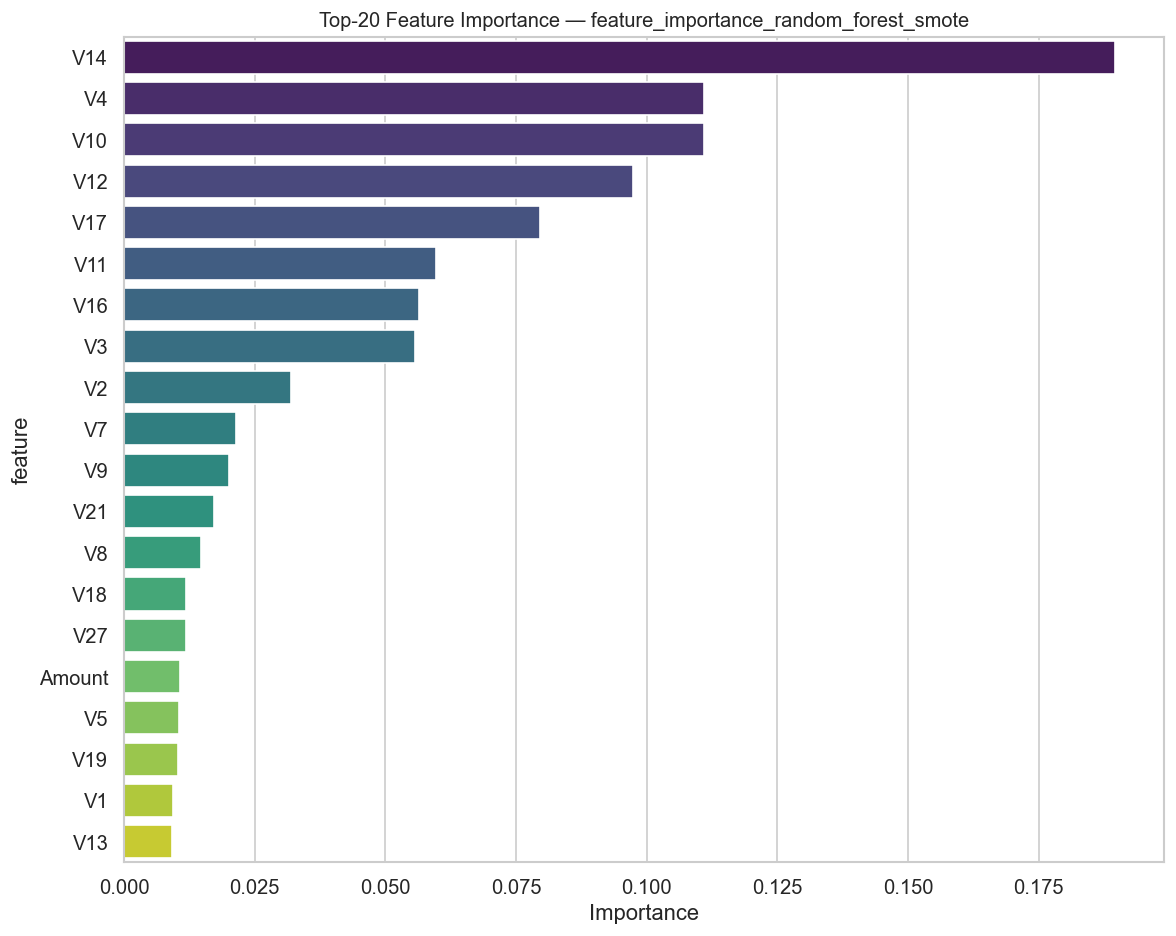

In [7]:
fi_files = list(REPORTS_DIR.glob('feature_importance_*.csv'))

if fi_files:
    fi_df = pd.read_csv(fi_files[0])
    
    fig, ax = plt.subplots(figsize=(10, 8))
    top20 = fi_df.head(20)
    sns.barplot(data=top20, x='importance', y='feature', ax=ax, palette='viridis')
    ax.set_title(f'Top-20 Feature Importance — {fi_files[0].stem}', fontsize=12)
    ax.set_xlabel('Importance')
    
    plt.tight_layout()
    plt.savefig(str(REPORTS_DIR / 'tuning_feature_importance_top20.png'))
    plt.show()
else:
    print('No feature importance files found.')

## 6. 🏆 Best Model Recommendation

In [8]:
if not results_df.empty and 'f1_score' in results_df.columns:
    # Rank by F1 (primary) and Recall (secondary)
    ranked = results_df.sort_values(['f1_score', 'recall'], ascending=False).reset_index(drop=True)
    ranked.index = ranked.index + 1  # 1-indexed rank
    ranked.index.name = 'Rank'
    
    print('🏆 MODEL RANKING (by F1-Score → Recall):')
    print('=' * 70)
    print(ranked.to_string())
    print('=' * 70)
    
    best = ranked.iloc[0]
    print(f'\n🥇 BEST MODEL: {best["model"]}')
    print(f'   Sampling:  {best["sampling"]}')
    print(f'   F1-Score:  {best["f1_score"]:.4f}')
    print(f'   Recall:    {best["recall"]:.4f}')
    print(f'   Precision: {best["precision"]:.4f}')
    if 'auc_roc' in best:
        print(f'   AUC-ROC:   {best["auc_roc"]:.4f}')
    
    # Save final ranking
    ranked.to_csv(REPORTS_DIR / 'final_model_ranking.csv')
    print('\n✅ Saved ranking → reports/final_model_ranking.csv')
else:
    print('No results to rank. Run the pipeline first.')

🏆 MODEL RANKING (by F1-Score → Recall):
                       model                sampling  accuracy  precision  recall  f1_score  auc_roc  auc_pr
Rank                                                                                                        
1              Random Forest                   smote    0.9995     0.8469  0.8469    0.8469   0.9661  0.8732
2        K-Nearest Neighbors                   smote    0.9985     0.5449  0.8673    0.6693   0.9434  0.6005
3     Support Vector Machine                   smote    0.9988     0.6739  0.6327    0.6526   0.8517  0.6294
4        Logistic Regression  baseline (no sampling)    0.9754     0.0606  0.9184    0.1138   0.9719  0.7093
5        Logistic Regression                   smote    0.9747     0.0591  0.9184    0.1110   0.9713  0.7222

🥇 BEST MODEL: Random Forest
   Sampling:  smote
   F1-Score:  0.8469
   Recall:    0.8469
   Precision: 0.8469
   AUC-ROC:   0.9661

✅ Saved ranking → reports/final_model_ranking.csv


## 7. Saved Model Artifacts

In [9]:
print('📁 Saved model files:')
for pkl_file in sorted(MODELS_DIR.glob('*.pkl')):
    size_mb = pkl_file.stat().st_size / 1e6
    print(f'  → {pkl_file.name:40s} ({size_mb:.1f} MB)')

print(f'\n📁 Report files:')
for report_file in sorted(REPORTS_DIR.glob('*')):
    size_mb = report_file.stat().st_size / 1e6
    print(f'  → {report_file.name:40s} ({size_mb:.2f} MB)')

📁 Saved model files:
  → knn_smote.pkl                            (112.8 MB)
  → logistic_regression_baseline.pkl         (0.0 MB)
  → logistic_regression_smote.pkl            (0.0 MB)
  → random_forest_smote.pkl                  (32.0 MB)
  → robust_scaler.pkl                        (0.0 MB)
  → svm_smote.pkl                            (0.6 MB)

📁 Report files:
  → all_models_smote_default.csv             (0.00 MB)
  → baseline_confusion_matrices.png          (0.06 MB)
  → baseline_metrics_comparison.png          (0.04 MB)
  → baseline_vs_sampling_comparison.csv      (0.00 MB)
  → best_params_knn.json                     (0.00 MB)
  → best_params_logistic_regression.json     (0.00 MB)
  → best_params_random_forest.json           (0.00 MB)
  → best_params_svm.json                     (0.00 MB)
  → cm_knn_smote.png                         (0.03 MB)
  → cm_knn_smote_default.png                 (0.03 MB)
  → cm_logistic_regression_baseline.png      (0.03 MB)
  → cm_logistic_regression_smo

---


**Kết quả:**
- Best params cho từng mô hình → `reports/best_params_*.json`
- Model comparison → `reports/model_comparison_*.csv`
- Final ranking → `reports/final_model_ranking.csv`
- Saved models → `models/*.pkl`

**Next steps (Ops phase):**
- Sử dụng best model `.pkl` + `robust_scaler.pkl` cho API inference
- Docker hoá ứng dụng
- Kết nối Power BI với PostgreSQL để dashboard real-time